<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 8: Signals and Sampling

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#signals" style="color:black;">Signals and Sinusoids</a></li>
    <li><a href="#audio" style="color:black;">Listening to Numerical Signals</a></li>
    <li><a href="#background_digital_audio" style="color:#1B5E20;"><strong>Background:</strong> From Sound Waves to Digital Audio</a></li>
    <li><a href="#sampling" style="color:black;">From Continuous to Discrete Time</a></li>
    <li><a href="#background_sampling" style="color:#1B5E20;"><strong>Background:</strong> The Sampling Theorem and Perfect Reconstruction</a></li>
    <li><a href="#aliasing" style="color:black;">Aliasing</a></li>
    <li><a href="#interference" style="color:black;">Interference and Beating</a></li>
    <li><a href="#exercise_beating" style="color:#006064;"><strong>Exercise 1:</strong> Interference and Beating</a></li>
    <li><a href="#exercise_aliasing_sinus" style="color:#006064;"><strong>Exercise 2:</strong> Aliasing of Sinusoids</a></li>
    <li><a href="#exercise_aliasing_visual" style="color:#006064;"><strong>Exercise 3:</strong> Visual Aliasing</a></li>
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A <strong>signal</strong> represents information through values that vary with time, space, or another independent variable. Examples include changing air pressure in sound, the brightness values of an image, and the sequence of images forming a video. In this unit, we focus on <strong>audio signals</strong>, which can be visualized as waveforms, stored as NumPy arrays, and reproduced through audio playback. We begin by constructing, displaying, and listening to <strong>sinusoidal signals</strong>. We then study <strong>sampling</strong>, which converts a continuous-time signal into a sequence of discrete values. This leads to the sampling theorem and to <strong>aliasing</strong>, where different continuous signals become indistinguishable after sampling. Finally, we examine <strong>interference</strong> and <strong>beating</strong>, connecting the addition of sinusoids to visible and audible effects. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Distinguish between continuous-time and discrete-time signals.</li>
<li>Generate, visualize, and play sinusoidal signals with specified parameters.</li>
<li>Relate the sampling period to the sampling rate and explain the main idea of the sampling theorem.</li>
<li>Recognize aliasing and explain why sampling may lose information.</li>
<li>Explain constructive and destructive interference and the origin of beating.</li>
<li>Use audio, image, and video objects in a Jupyter notebook.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_beating">Exercise 1</a>: Investigate interference and beating.</li>
<li><a href="#exercise_aliasing_sinus">Exercise 2</a>: Explore the aliasing of sinusoids.</li>
<li><a href="#exercise_aliasing_visual">Exercise 3</a>: Examine visual aliasing through the wagon-wheel effect.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
Related material is available in the <a href="https://www.audiolabs-erlangen.de/FMP">FMP Notebooks</a>, particularly the notebooks on <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2S2_DigitalSignalSampling.html">digital signal sampling</a> and <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2S3_InterferenceBeating.html">interference and beating</a>, which provided a basis for parts of this unit.
</p>

</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
import IPython.display as ipd

# --- Custom utilities (Unit 8) ---
from libpcp.unit08 import (
    exercise_beating,
    exercise_aliasing_sinus,
    exercise_aliasing_visual,
)

# --- Figure format and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="signals"></a>
## Signals and Sinusoids

A **signal** is a function that assigns a value to each permitted value of an independent variable. In this unit, that variable is time. A real-valued **continuous-time signal** can therefore be written as

$$
f:\mathbb{R}\to\mathbb{R},
\qquad
t\mapsto f(t),
$$

where $t\in\mathbb{R}$ denotes time and $f(t)\in\mathbb{R}$ is the corresponding signal value. For an acoustic signal, $f(t)$ may represent the deviation of the air pressure from a reference pressure. Positive and negative values then indicate pressure above and below this reference level. An important example is the **sinusoidal signal**

$$
f(t):=A\sin\bigl(2\pi(\omega t-\varphi)\bigr),
\qquad t\in\mathbb{R}.
$$

Its behavior is determined by three parameters:

* The **amplitude** $A\geq0$ determines the largest absolute signal value.
* The **frequency** $\omega>0$, measured in hertz (Hz), specifies the number of oscillations per second. One oscillation therefore lasts $1/\omega$ seconds.
* The **phase** $\varphi$ determines the position of the oscillation within one cycle.

The factor $2\pi$ converts cycles into angles measured in radians. We use the normalized phase $\varphi\in[0,1)$, where $1$ corresponds to one complete cycle. Thus, $\varphi=1/4$ shifts the sinusoid by one quarter of a cycle. Equivalently, phase could be expressed as an angle in $[0,2\pi)$ and measured directly in radians.

The mathematical function $f$ is defined at every real time, but a computer can store only finitely many values. For a numerical representation, we choose a **duration** and evaluate the function at equally spaced time points determined by a **sampling rate**. The resulting time points and signal values are stored in NumPy arrays. This is already a form of sampling, which we will examine carefully later. The following code defines one function for generating this numerical representation and another for plotting it. The markers indicate the stored values, while the connecting lines help reveal the shape of the sinusoid:

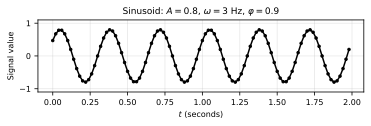

In [2]:
def generate_sinusoid(duration=1, amplitude=1, frequency=1, phase=0, sr=4000):
    """Generate a sampled sinusoid."""
    t = np.arange(int(duration * sr)) / sr
    x = amplitude * np.sin(2 * np.pi * (frequency * t - phase))
    return x, t, sr


def plot_signal(x, t, title='Signal', show_samples=False,
                figsize=(5.2, 1.8), color='black'):
    """Plot a signal over time."""
    marker = 'o' if show_samples else None
    plt.figure(figsize=figsize, layout='tight')
    plt.plot(t, x, color=color, marker=marker, markersize=2.5)
    plt.xlabel('$t$ (seconds)')
    plt.ylabel('Signal value')
    plt.title(title)
    plt.grid(alpha=0.3)


amp, freq, phase = 0.8, 3, 0.9

x, t, sr = generate_sinusoid(
    duration=2, amplitude=amp, frequency=freq, phase=phase, sr=50
)

title = rf'Sinusoid: $A={amp}$, $\omega={freq}$ Hz, $\varphi={phase}$'
plot_signal(x, t, title=title, show_samples=True)
plt.ylim(-1.1, 1.1);

In this example, the two-second interval is represented by $100$ stored values. At a frequency of $3$ Hz, the signal completes six oscillations, with approximately $17$ samples per cycle. The markers show the stored values, while the connecting line helps reveal the sinusoidal shape but does not represent additional samples. By changing the arguments of `generate_sinusoid()`, we can independently control the amplitude, frequency, phase, duration, and numerical resolution of the signal.

<a id="audio"></a>
## Listening to Numerical Signals

A NumPy array contains an ordered sequence of values, but it does not specify how much physical time passes between them. For audio playback, the array must therefore be combined with a **sampling rate**, commonly abbreviated as `sr`. For example, audio CDs use $44\,100$ samples per second, a rate widely used for high-quality audio.

The previous frequency of $3$ Hz is too low to be perceived as a musical pitch. We therefore generate a two-second sinusoid at $440$ Hz, corresponding to the musical note A4, with amplitude $0.2$ and a sampling rate of $4000$ Hz. This rate is sufficient for our example and keeps the array small: it contains $2\cdot4000=8000$ values ranging from $-0.2$ to $0.2$.

The function `generate_sinusoid()` returns the signal values, their corresponding time points, and the sampling rate. In the following call, `_` indicates that the time array is not needed. The function `ipd.Audio()` then creates an audio player from the signal values, while its keyword argument `rate` specifies how many samples are played per second:

In [3]:
sr = 4000

# Generate two seconds of the pitch A4
x_audio, _, sr = generate_sinusoid(
    duration=2, amplitude=0.2, frequency=440, phase=0, sr=sr
)

# Play the signal at 4000 samples per second
ipd.Audio(x_audio, rate=sr, normalize=False)

The array determines the waveform, while the sampling rate determines how quickly its values are played. The following background box places this small Python example in the broader process of recording, storing, and reproducing sound.

<a id="background_digital_audio"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: From Sound Waves to Digital Audio
</h2>

<div style="
  float:right;
  width:230px;
  max-width:42%;
  margin-left:20px;
  margin-bottom:10px;
">
<img src="data/PCP_fig_wave_longitudal.png"
     style="display:block; width:100%; height:auto;"
     alt="Sound wave with regions of high and low air pressure">
</div>

<p style="color:#1B5E20;">
Sound begins with a vibrating object, such as the vocal folds of a singer, a violin string, or a loudspeaker membrane. The vibration moves nearby air molecules back and forth, creating regions of higher and lower density and pressure, as shown in the figure. This changing pressure travels through the air as a <strong>sound wave</strong>, while the individual molecules mainly oscillate around their local positions. In this respect, sound resembles a stadium wave: the pattern moves forward, although the people creating it remain near their seats. The figure shows the wave across space at one moment. A microphone records another view by measuring the pressure at one fixed position over time. Plotting these values produces a <strong>waveform</strong>, which shows the pressure deviation from its average level. The microphone converts these changes into a continuously varying electrical signal.
</p>

<p style="color:#1B5E20;">
Before a computer can store this signal, it must be converted into finitely many numbers. <strong>Sampling</strong> measures its value at regularly spaced moments, replacing continuous time with discrete time points. <strong>Quantization</strong> assigns each measurement to one of finitely many levels, replacing continuous amplitudes with discrete values. The <strong>sampling rate</strong> specifies the number of measurements per second, while the <strong>bit depth</strong> determines how many levels are available. An <a href="https://en.wikipedia.org/wiki/Compact_Disc_Digital_Audio">audio CD</a>, for example, uses $44\,100$ samples per second, $16$ bits per sample, and two stereo channels. This produces $44\,100\cdot16\cdot2=1\,411\,200$ bits, or about $1.41$ megabits, per second. One hour of uncompressed audio therefore requires approximately $635$ megabytes, and a conventional audio CD typically holds about $74$ to $80$ minutes of music.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
During <strong>playback</strong>, the process is reversed: the stored numbers become an electrical signal, and a loudspeaker turns it back into changing air pressure. The sampling rate determines how quickly the values are played. A higher rate makes the sound shorter and raises its frequencies; a lower rate makes it longer and lowers them. Under suitable conditions, the CD sampling rate can represent frequencies below $22\,050$ Hz, slightly above the commonly stated upper limit of human hearing near $20\,000$ Hz. We will explain this relationship through the sampling theorem. Although speech and music are far more complex than a single sinusoid, sinusoids remain useful building blocks for understanding them.    
</p>

<div style="clear:both;"></div>
</div>

Having seen how sound is represented digitally, let us explore **pitch**, the perceptual attribute that orders tones from low to high. For pure sinusoids, pitch is closely related to frequency. In scientific pitch notation, the letter names the note and the number identifies its **octave**. The reference pitch A4, also known as **concert pitch**, has a frequency of $440$ Hz; A3 and A5 have frequencies of $220$ and $880$ Hz. Thus, doubling or halving the frequency preserves the note name while shifting the pitch by one octave. Listen to these three versions of A:


In [4]:
sr = 4000

# Generate and play the note A in three neighboring octaves
for note, freq in [('A3', 220), ('A4', 440), ('A5', 880)]:
    x_audio, _, sr = generate_sinusoid(
        amplitude=0.2, frequency=freq, sr=sr
    )
    print(f'{note}: {freq} Hz')
    ipd.display(ipd.Audio(x_audio, rate=sr, normalize=False))

A3: 220 Hz


A4: 440 Hz


A5: 880 Hz


Two sounds can have the same pitch and still sound very different. A sinusoid contains only one frequency and is therefore perceived as a **pure tone**. Musical instruments usually produce a fundamental frequency together with weaker oscillations at integer multiples of it, called **harmonics**. The fundamental largely determines the pitch, while the number and relative strengths of the harmonics contribute to the **timbre**, or tone color. The following simplified signals all have the fundamental frequency $220$ Hz but different harmonic mixtures:

In [5]:
sr = 4000
freq = 220  # Fundamental frequency of A3

# Pure tone containing only the fundamental
x_pure, _, _ = generate_sinusoid(amplitude=0.2, frequency=freq, sr=sr)

# Add the first five harmonics with decreasing amplitudes
x_harmonic = sum(
    generate_sinusoid(amplitude=0.15 / k, frequency=freq * k, sr=sr)[0]
    for k in range(1, 6)
)

# Retain only the first three odd harmonics
x_odd_harmonic = sum(
    generate_sinusoid(amplitude=0.18 / k, frequency=freq * k, sr=sr)[0]
    for k in [1, 3, 5]
)

for label, signal in [
    ('Pure A3', x_pure),
    ('A3 with five harmonics', x_harmonic),
    ('A3 with odd harmonics', x_odd_harmonic),
]:
    print(label)
    ipd.display(ipd.Audio(signal, rate=sr, normalize=False))

Pure A3


A3 with five harmonics


A3 with odd harmonics


Real sounds are usually far more complex than a single sinusoid. Several pitched tones may occur at the same time and combine to create **harmony**. A selected group of simultaneous notes forms a **chord**, while several independent melodic lines produce **polyphonic music**. Even one note played by a real instrument typically contains many frequencies and changes over time. Not every sound has a clear pitch or a regularly repeating waveform. **Noise** contains irregular changes and may resemble the sound of wind or a waterfall. In Gaussian noise, the signal values are chosen randomly according to a normal distribution. Other sounds are defined by their short duration: clicks, hand claps, and drum attacks appear suddenly and disappear quickly. Such brief events are called **transients**. We conclude our audio exploration with three contrasting signals: a C-major chord, Gaussian noise, and a single click. They range from musical harmony to an irregular rushing sound and finally to one isolated event, yet Python represents all three in the same way as NumPy arrays.

In [6]:
sr = 4000

# Add three sinusoids to form a C-major chord
chord_freqs = [261.63, 329.63, 392.00]
x_chord = sum(
    generate_sinusoid(duration=1, amplitude=0.08, frequency=freq, sr=sr)[0]
    for freq in chord_freqs
)

# Generate one second of reproducible Gaussian noise
rng = np.random.default_rng(0)
x_noise = 0.05 * rng.standard_normal(sr)

# Create a single impulse after half a second
x_click = np.zeros(sr)
x_click[sr // 2] = 0.8

# Play the three signals without automatic normalization
for label, signal in [
    ('C-major chord', x_chord),
    ('Gaussian noise', x_noise),
    ('Single click', x_click),
]:
    print(label)
    ipd.display(ipd.Audio(signal, rate=sr, normalize=False))

C-major chord


Gaussian noise


Single click


<a id="sampling"></a>

## Sampling: From Continuous to Discrete Time

As described in the background box on <a href="#background_digital_audio">sound waves and digital audio</a>, sampling converts a continuously varying signal into a sequence of measurements. We now formulate this process mathematically and investigate how the resulting discrete-time signal relates to the original continuous-time signal.

Let $f:\mathbb{R}\to\mathbb{R}$ be a continuous-time signal. In **uniform sampling**, its values are measured at equally spaced time points

$$
t_n:=nT,
\qquad n\in\mathbb{Z},
$$

where $T>0$ is the **sampling period**, measured in seconds. The resulting **discrete-time signal** is

$$
x[n]:=f(t_n)=f(nT),
\qquad n\in\mathbb{Z}.
$$

Thus, $f(t)$ is defined for every real time $t$, whereas $x[n]$ is defined only at integer sample indices $n$. The reciprocal of the sampling period,

$$
F_{\mathrm{s}}:=\frac{1}{T},
$$

is the **sampling rate**, measured in hertz. It specifies the number of samples taken per second. For example, $F_{\mathrm{s}}=100$ Hz corresponds to a sampling period of $T=1/100=0.01$ seconds.

The mathematical sequence $x$ may be defined for all integers, but a recording has a finite duration. A signal of duration $D$ seconds sampled at $F_{\mathrm{s}}$ Hz contains approximately $N=D F_{\mathrm{s}}$ values, indexed by $n=0,\ldots,N-1$. The corresponding time points used in Python are $t_n=n/F_{\mathrm{s}}$. Sampling discretizes time but does not yet restrict the possible signal values; that separate step is quantization.

To illustrate sampling, we use a signal composed of three sinusoids with frequencies $1.9$, $6.1$, and $20$ Hz and decreasing amplitudes. This mixture contains both slowly and rapidly changing components. The function `generate_example_signal()` evaluates it at a specified sampling rate.

Since a computer cannot store a genuinely continuous-time signal, we first evaluate the function at $100$ Hz and use the resulting dense array as a numerical reference. The function `sampling_equidistant()` then obtains a more sparsely sampled version by interpolating the reference values at new, equally spaced time points:

In [11]:
def generate_example_signal(duration=1, sr=100):
    """Generate the example signal."""
    N = int(round(sr * duration))
    t = np.arange(N) / sr
    x = np.sin(2 * np.pi * (1.9 * t - 0.3))
    x += 0.5 * np.sin(2 * np.pi * (6.1 * t - 0.1))
    x += 0.1 * np.sin(2 * np.pi * (20 * t - 0.2))
    return x, t


def sampling_equidistant(x_ref, t_ref, sr, duration=None):
    """Sample an interpolated reference signal at equally spaced times."""
    if duration is None:
        duration = t_ref[-1] + t_ref[1] - t_ref[0]
    N = int(round(sr * duration))
    t = np.arange(N) / sr
    x = np.interp(t, t_ref, x_ref)
    return x, t

We generate a two-second reference signal at $100$ Hz and sample it at $20$ Hz:
duration = 2
The upper panel shows the densely sampled reference signal. The lower panel shows the values retained when the signal is sampled at $20$ Hz. The gray dotted curve is included only to show where the samples lie relative to the reference:

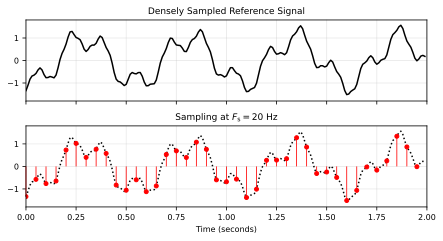

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(6.2, 3.4),
                         layout='tight', sharex=True)

axes[0].plot(t_ref, x_ref, color='black')
axes[0].set_title('Densely Sampled Reference Signal')

axes[1].plot(t_ref, x_ref, color='black', linestyle=':')
markers, stems, _ = axes[1].stem(
    t, x, linefmt='r-', markerfmt='ro', basefmt=' '
)
markers.set_markersize(4)
stems.set_linewidth(0.8)
axes[1].set_title(r'Sampling at $F_\mathrm{s}=20$ Hz')
axes[1].set_xlabel('Time (seconds)')

for ax in axes:
    ax.set_xlim(0, duration)
    ax.set_ylim(-1.8, 1.8)
    ax.grid(alpha=0.3)

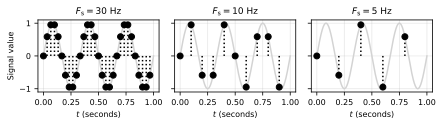

In [7]:
duration, freq = 1, 3
t_dense = np.linspace(0, duration, 1001)
f_dense = np.sin(2 * np.pi * freq * t_dense)

fig, axes = plt.subplots(1, 3, figsize=(6.2, 1.8),
                         layout='tight', sharey=True)

for ax, sr in zip(axes, [30, 10, 5]):
    x, t, _ = generate_sinusoid(
        duration=duration, frequency=freq, sr=sr
    )
    ax.plot(t_dense, f_dense, color='lightgray')
    ax.stem(t, x, linefmt='k:', markerfmt='ko', basefmt=' ')
    ax.set_title(rf'$F_\mathrm{{s}}={sr}$ Hz')
    ax.set_xlabel('$t$ (seconds)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Signal value');

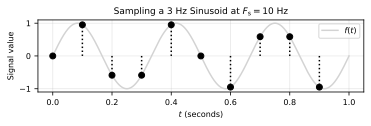

In [8]:
duration, freq = 1, 3
t_dense = np.linspace(0, duration, 1001)
f_dense = np.sin(2 * np.pi * freq * t_dense)

Fs = 10
x, t, _ = generate_sinusoid(duration=duration, frequency=freq,
                         sampling_rate=Fs)

plt.figure(figsize=(5.2, 1.8), layout='tight')
plt.plot(t_dense, f_dense, color='lightgray', label='$f(t)$')
plt.stem(t, x, linefmt='k:', markerfmt='ko', basefmt=' ')
plt.xlabel('$t$ (seconds)')
plt.ylabel('Signal value')
plt.title(rf'Sampling a {freq} Hz Sinusoid at $F_\mathrm{{s}}={Fs}$ Hz')
plt.grid(alpha=0.3)
plt.legend();

<a id='sampling'></a> 
## Sampling

In digital signal processing, one often reduces a **continuous-time** (CT) signal $f\colon\mathbb{R}\to\mathbb{R}$ into a **discrete-time** (DT) signal $x\colon\mathbb{Z}\to\mathbb{R}$ by a procedure known as **equidistant sampling**. Fixing a positive real number $T>0$, the DT-signal $x$ is obtained by setting 

\begin{equation*}
   x(n):= f(n \cdot T)
\end{equation*}

for $n\in\mathbb{Z}$. The value $x(n)$ is called the **sample** taken at time $t=n\cdot T$ of the original analog signal $f$. In short, this procedure is also called **$T$-sampling**. The number $T$ is referred to as the **sampling period** and the inverse $F_\mathrm{s}:=1/T$ as the **sampling rate**. The sampling rate specifies the number of samples per second and is measured in Hertz (Hz). 

In the following code cell, we start with a CT-signal $f$ that is defined via linear interpolation of a DT-signal sampled at a high sampling rate (generated by the `generate_example_function`). In the plot, this CT-signal is visualized as black curve. Applying equidistant sampling (`sampling_equidistant`), we obtain the DT-signal visualized as the red stem plot.

In [ ]:
def generate_example_signal(dur=1, Fs=100):
    """Generate example signal

    Notebook: PCP_08_signal.ipynb

    Args:
        dur: Duration (in seconds) of signal (Default value = 1)
        Fs: Sampling rate (in samples per second) (Default value = 100)

    Returns:
        x: Signal
        t: Time axis (in seconds)
    """
    N = int(Fs * dur)
    t = np.arange(N) / Fs
    x = 1 * np.sin(2 * np.pi * (1.9 * t - 0.3))
    x += 0.5 * np.sin(2 * np.pi * (6.1 * t - 0.1))
    x += 0.1 * np.sin(2 * np.pi * (20 * t - 0.2))
    return x, t

def sampling_equidistant(x_1, t_1, Fs_2, dur=None):
    """Equidistant sampling of interpolated signal

    Notebook: PCP_08_signal.ipynb

    Args:
        x_1: Signal to be interpolated and sampled
        t_1: Time axis (in seconds) of x_1
        Fs_2: Sampling rate used for equidistant sampling
        dur: Duration (in seconds) of sampled signal (Default value = None)

    Returns:
        x_2: Sampled signal
        t_2: time axis (in seconds) of sampled signal
    """
    if dur is None:
        dur = len(t_1) * t_1[1]
    N = int(Fs_2 * dur)
    t_2 = np.arange(N) / Fs_2
    x_2 = np.interp(t_2, t_1, x_1)
    return x_2, t_2
    
Fs_1 = 100
x_1, t_1 = generate_example_signal(Fs=Fs_1, dur=2)

Fs_2 = 20
x_2, t_2 = sampling_equidistant(x_1, t_1, Fs_2)
    
plt.figure(figsize=(6.2, 2.0), layout='tight')
plt.plot(t_1, x_1, 'k')
plt.title('Original CT-signal')
plt.xlabel('Time (seconds)')
plt.ylim([-1.8, 1.8])
plt.xlim([t_1[0], t_1[-1]])

plt.figure(figsize=(6.2, 2.0), layout='tight')
plt.stem(t_2, x_2, linefmt='r', markerfmt='ro', basefmt='None')
plt.plot(t_1, x_1, 'k', linewidth=1, linestyle='dotted')
plt.title(r'DT-Signal obtained by sampling with $F_\mathrm{s} = %.0f$' % Fs_2)
plt.xlabel('Time (seconds)')
plt.ylim([-1.8, 1.8])
plt.xlim([t_1[0], t_1[-1]])

plt.figure(figsize=(6.2, 2.0), layout='tight')
plt.stem(x_2, linefmt='r', markerfmt='ro', basefmt='None')
plt.title(r'DT-Signal')
plt.xlabel('Time (samples)')
plt.ylim([-1.8, 1.8])
plt.xlim([0, len(t_2)])

<a id='aliasing'></a> 
## Aliasing

In general, sampling is a **lossy** operation in the sense that information is lost in this process and that the original CT-signal cannot be recovered from its sampled version. Only if the CT-signal has additional properties in terms of its frequency spectrum (it needs to be **bandlimited**), a perfect reconstruction is possible. This is the assertion of the famous **sampling theorem**. The sampling theorem also shows how the original CT-signal can be reconstructed by superimposing suitably shifted $\mathrm{sinc}$-functions weighted by the samples of the DT-signal.

<a id='background_sampling'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Sampling Theorem</h2>
<p style="color:#1B5E20;">
The <strong>sampling theorem</strong>, which is often associated with the names Harry Nyquist and Claude Shannon, states that a continuous-time (CT) signal that is bandlimited can be reconstructed perfectly under certain conditions. More precisely, a CT-signal $f\in L^2(\mathbb{R})$ is called <strong>$\Omega$-bandlimited</strong> if the Fourier transform $\hat{f}$ vanishes for $|\omega|>\Omega$ (i.e., $\hat{f}(\omega) = 0$ for $|\omega|>\Omega$). Let $f\in L^2(\mathbb{R})$ be an $\Omega$-bandlimited function and let $x$ be the $T$-sampled version of $f$ with $T:=1/(2\Omega)$ (i.e., $x(n)=f(nT)$, $n\in\mathbb{Z}$). Then $f$ can be reconstructed from $x$ by
$$
 f(t)=\sum_{n\in\mathbb{Z}}x(n)\mathrm{sinc}\left(\frac{t-nT}{T}\right)
 =\sum_{n\in\mathbb{Z}}f\left(\frac{n}{2\Omega}\right) \mathrm{sinc}\left(2\Omega t-n\right),
$$
where the $\mathrm{sinc}$-function is defined as
\begin{equation}
    \mathrm{sinc}(t):=\left\{\begin{array}{ll}
    \frac{\sin \pi t}{\pi t},&\mbox{ if $t\not= 0$,}\\
    1,&\mbox{ if $t= 0$.}
\end{array}\right.
\end{equation}
In other words, the CT-signal $f$ can be perfectly reconstructed from the DT-signal obtained by equidistant sampling if the bandlimit is no greater than half the sampling rate. This reconstruction based on the $\mathrm{sinc}$-function has been used in the function `reconstruction_sinc`.
</div>

Without additional properties, sampling may cause an effect known as **aliasing** where certain frequency components of the signal become indistinguishable. This effect is illustrated by the following figure. Using a high sampling rate, the original CT-signal can be reconstructed with high accuracy. However, when decreasing the sampling rate, the higher-frequency components are not captured well and only a coarse approximation of the original signal remains. This phenomenon is demonstrated by the following example.

In [ ]:
def reconstruction_sinc(x, t, t_sinc):
    """Reconstruction from sampled signal using sinc-functions

    Notebook: PCP_08_signal.ipynb

    Args:
        x: Sampled signal
        t: Equidistant discrete time axis (in seconds) of x
        t_sinc: Equidistant discrete time axis (in seconds) for reconstructed signal 

    Returns:
        x_sinc: Reconstructed signal having time axis t_sinc
    """
    Fs = 1 / t[1]
    x_sinc = np.zeros(len(t_sinc))
    for n in range(0, len(t)):
        x_sinc += x[n] * np.sinc(Fs * t_sinc - n)
    return x_sinc

def plot_signal_reconstructed(t_1, x_1, t_2, x_2, t_sinc, x_sinc, figsize=(6.2, 2.0)):
    """Plotting three signals

    Notebook: PCP_08_signal.ipynb

    Args:
        t_1: Time axis of original signal
        x_1: Original signal
        t_2: Time axis for sampled signal
        x_2: Sampled signal
        t_sinc: Time axis for reconstructed signal
        x_sinc: Reconstructed signal
        figsize: Figure size (Default value = (8, 2.2))
    """
    plt.figure(figsize=figsize, layout='tight')
    plt.plot(t_1, x_1, 'k', linewidth=1, linestyle='dotted', label='Orignal signal')
    plt.stem(t_2, x_2, linefmt='r:', markerfmt='r.', basefmt='None', label='Samples')
    plt.plot(t_sinc, x_sinc, 'b', label='Reconstructed signal')
    plt.title(r'Sampling rate $F_\mathrm{s} = %.0f$' % (1/t_2[1]))
    plt.xlabel('Time (seconds)')
    plt.ylim([-1.8, 1.8])
    plt.xlim([t_1[0], t_1[-1]])
    plt.legend(loc='upper right', framealpha=1)
    plt.show()

Fs_2 = 40
x_2, t_2 = sampling_equidistant(x_1, t_1, Fs_2)
t_sinc = t_1
x_sinc = reconstruction_sinc(x_2, t_2, t_sinc)
plot_signal_reconstructed(t_1, x_1, t_2, x_2, t_sinc, x_sinc)

Fs_2 = 20
x_2, t_2 = sampling_equidistant(x_1, t_1, Fs_2)
t_sinc = t_1
x_sinc = reconstruction_sinc(x_2, t_2, t_sinc)
plot_signal_reconstructed(t_1, x_1, t_2, x_2, t_sinc, x_sinc)

Fs_2 = 10
x_2, t_2 = sampling_equidistant(x_1, t_1, Fs_2)
t_sinc = t_1
x_sinc = reconstruction_sinc(x_2, t_2, t_sinc)
plot_signal_reconstructed(t_1, x_1, t_2, x_2, t_sinc, x_sinc)

<a id='interference'></a> 
## Interference

In signal processing, **interference** occurs when a wave is superimposed with another wave that has the same or nearly the same frequency. When a crest of one wave meets a crest of the other wave at some point, then the individual magnitudes add up for a certain period of time, which is known as **constructive interference**. Vice versa, when a crest of one wave meets a trough of the other wave, then the magnitudes cancel out for a certain period of time, which is known as **destructive interference**. We illustrate these phenomena in the following code cell. 

In [ ]:
def plot_interference(t, x1, x2, figsize=(8, 2), xlim=None, ylim=None, title=''):
    """Plotting two signals and its superposition

    Notebook: PCP_08_signal.ipynb

    Args:
        t: Time axis
        x1: Signal 1
        x2: Signal 2
        figsize: Figure size (Default value = (8, 2))
        xlim: x-Axis limits (Default value = None)
        ylim: y-Axis limits (Default value = None)
        title: Figure title (Default value = '')
    """    
    plt.figure(figsize=(6.2, 2.0), layout='tight')
    plt.plot(t, x1, color='gray', linewidth=1.0, linestyle='-', label='x1')
    plt.plot(t, x2, color='cyan', linewidth=1.0, linestyle='-', label='x2')
    plt.plot(t, x1+x2, color='red', linewidth=2.0, linestyle='-', label='x1+x2')
    if xlim is None:
        plt.xlim([0, t[-1]])
    else:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.show()

dur = 5
x1, t = generate_sinusoid(dur=dur, Fs=100, amp=1, freq=1.05, phase=0.0)
x2, t = generate_sinusoid(dur=dur, Fs=100, amp=1, freq=0.95, phase=0.8)
plot_interference(t, x1, x2, xlim=[0, dur], ylim=[-2.2,2.2], 
                  title='Constructive Interference')

dur = 5
x1, t = generate_sinusoid(dur=dur, Fs=100, amp=1, freq=1.05, phase=0.0)
x2, t = generate_sinusoid(dur=dur, Fs=100, amp=1, freq=1.00, phase=0.4)
plot_interference(t, x1, x2, xlim=[0, dur], ylim=[-2.2,2.2], 
                  title='Destructive Interference')

<a id='exercise_beating'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Beating</strong>
<p style="color:#006064;">
Let $f_1(t)=\sin(2\pi \omega_1 t)$ and $f_2(t)=\sin(2\pi \omega_2 t)$ be two sinusoids with distinct but nearby frequencies $\omega_1\approx\omega_2$. The superposition $f_1+f_2$ of these two sinusoids results in a function that looks like a single sine wave with a slowly varying amplitude, a phenomenon also known as <strong>beating</strong>. Mathematically, this phenomenon results from a <strong>trigonometric identity</strong> yielding 
$$
\sin(2\pi \omega_1 t)+\sin(2\pi \omega_2 t)=
2\cos\left(2\pi\frac{\omega_1-\omega_2}{2}t\right)\sin\left(2\pi\frac{\omega_1+\omega_2}{2}t\right).
$$
If the difference $\omega_1-\omega_2$ is small, the cosine term has a low frequency compared to the sine term. As a result the signal $f_1+f_2$ can be seen as a sine wave of frequency $(\omega_1+\omega_2)/2$ with a slowly varying amplitude envelope of frequency $|\omega_1-\omega_2|$. Note that this rate is twice the frequency $(\omega_1-\omega_2)/2$ of the cosine term. 
</p>
<ul style="color:#006064;"> 
    <li>Use the functions <code>generate_sinusoid</code> and <code>plot_interference</code> to  illustrate the beating effect for various parameters $\omega_1$ and $\omega_2$.</li> 
    <li>In particular, consider $\omega_1=200$ and $\omega_2=203$ to generate a superimposed signal <code>x</code> at a sampling rate of <code>Fs=4000</code>. Listen to <code>x</code> using <code>ipd.display(ipd.Audio(x, rate=Fs))</code>.</li>
</ul>    
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_beating() 

<a id='exercise_aliasing_sinus'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Aliasing with Sinsuoids</strong>
<p style="color:#006064;">
First, using <code>x, t = generate_sinusoid(dur=2, Fs=128, freq=10)</code>, generate a sinusoid of frequency $\omega=10~\mathrm{Hz}$ at <code>Fs=128</code> to mimic a CT-signal. Then, use the function <code>sampling_equidistant</code> to successively decrease the sampling rate using <code>[64, 32, 20, 16, 12, 8, 4]</code>. Visualize the result via <code>plot_signal_reconstructed</code> and discuss your observations.
</p>
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_aliasing_sinus() 

<a id='exercise_aliasing_visual'></a> 
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Visual Aliasing</strong>
<p style="color:#006064;">
Aliasing effects occur also in other areas such as the visual domain. One famous example is the <strong>wagon-wheel effect</strong>, where a wheel appears to rotate at a slower speed or even backwards when the speed is actually increasing. Identify some YouTube videos that illustrate this effect. Furthermore, integrate the video into your notebooks. To this end, do the following:
</p>
<ul style="color:#006064;">
    <li> Import the <a href='https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html'>API for display tools in IPython</a>: <code>import IPython.display as ipd</code>.  </li>
    <li> Use the following commands: <code>ipd.display</code>, <code>ipd.YouTubeVideo</code></li>    
</ul>
</div>

In [ ]:
# Your Solution

In [ ]:
# exercise_aliasing_visual() 

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>